# Analyzation of Wind Speed for Masked Forecasts

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from typing import Union, Optional, List

In [8]:
def plot_mean_wind_speed_comparison(
    masked_folder: str,
    input_path: Union[str, os.PathLike],
    region_lat: slice = slice(55.0, 53.0),
    region_lon: slice = slice(7.5, 10.5),
    title: str = "Mean Wind Speed at 22:00 UTC over North Germany (10m) – Feature Occlusion",
    rename_map: Optional[dict] = None,
    order: Optional[List[str]] = None,
    order_by_size: bool = False,
):
    def mean_wind_speed(ds, time_sel=None):
        if time_sel is not None:
            u10 = ds["10m_u_component_of_wind"].isel(time=time_sel)
            v10 = ds["10m_v_component_of_wind"].isel(time=time_sel)
        else:
            u10 = ds["10m_u_component_of_wind"].squeeze()
            v10 = ds["10m_v_component_of_wind"].squeeze()

        wind_speed = np.sqrt(u10**2 + v10**2)
        return wind_speed.sel(lat=region_lat, lon=region_lon).mean().item()

    wind_means = {}

    # Unmasked
    unmasked_ds = xr.open_dataset(input_path)
    if "time" in unmasked_ds and unmasked_ds.time.size > 1:
        try:
            time_sel = int(np.where(unmasked_ds.time.dt.hour == 22)[0][0])
        except (AttributeError, IndexError):
            time_sel = 0
    else:
        time_sel = None

    unmasked_mean = mean_wind_speed(unmasked_ds, time_sel)

    # Masked
    for fname in sorted(os.listdir(masked_folder)):
        if not fname.endswith(".nc"):
            continue
        path = os.path.join(masked_folder, fname)
        ds = xr.open_dataset(path)
        label = fname.replace("masked_", "").replace(".nc", "")
        display_label = rename_map[label] if rename_map and label in rename_map else label
        wind_means[display_label] = mean_wind_speed(ds)

    # Apply custom order if provided
    if order:
        labels = [lbl for lbl in order if lbl in wind_means]
    else:
        labels = list(wind_means.keys())

    values = [wind_means[lbl] for lbl in labels]

    # Optionally order by size
    if order_by_size:
        sorted_pairs = sorted(zip(values, labels))
        values, labels = zip(*sorted_pairs)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(labels, values, color='skyblue')
    plt.axhline(unmasked_mean, color='black', linestyle='--', label='Unmasked Reference')
    plt.ylabel("10m Wind Speed at 22:00 UTC (m/s)")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [3]:
input_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
original_prediction_path="../data/prediction_zeynep_22/predictions/zeynep_22_prediction_graphcast_small.nc"

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipyker

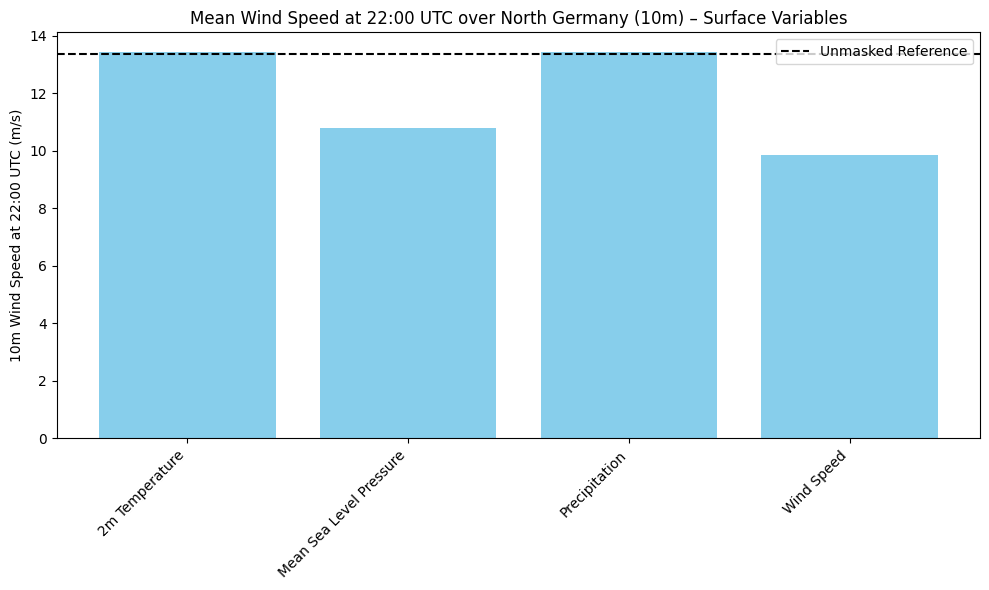

In [5]:
rename_map = {
    "2m_temperature_levnone_regnone_tnone": "2m Temperature",
    "10m_u_component_of_wind_levnone_regnone_tnone": "U Wind 10m",
    "10m_v_component_of_wind_levnone_regnone_tnone": "V Wind 10m",
    "mean_sea_level_pressure_levnone_regnone_tnone": "Mean Sea Level Pressure",
    "total_precipitation_6hr_levnone_regnone_tnone": "Precipitation",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone_regnone_tnone": "Wind Speed"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/surface_variables",
    input_path=original_prediction_path,
    title = "Mean Wind Speed at 22:00 UTC over North Germany (10m) – Surface Variables",
    rename_map=rename_map,
    order=[
        "2m Temperature",
        "Mean Sea Level Pressure",
        "Precipitation",
        "Wind Speed"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipyker

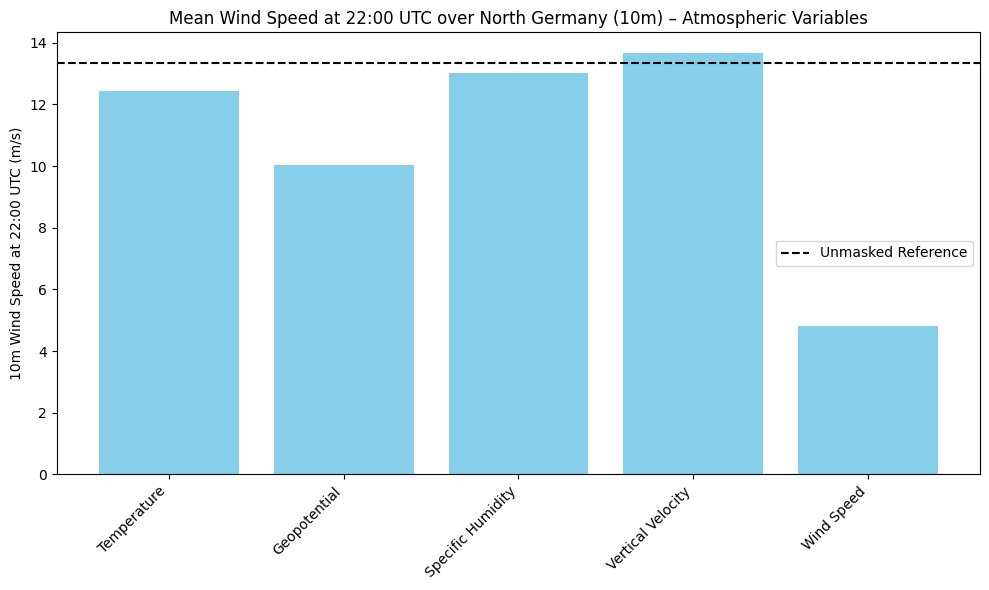

In [7]:
rename_map = {
    "temperature_levnone_regnone_tnone": "Temperature",
    "u_component_of_wind_levnone_regnone_tnone": "U Wind",
    "v_component_of_wind_levnone_regnone_tnone": "V Wind",
    "geopotential_levnone_regnone_tnone": "Geopotential",
    "vertical_velocity_levnone_regnone_tnone": "Vertical Velocity",
    "specific_humidity_levnone_regnone_tnone": "Specific Humidity",
    "('u_component_of_wind', 'v_component_of_wind')_levnone_regnone_tnone": "Wind Speed"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/atmospheric_variables",
    input_path=original_prediction_path,
    title = "Mean Wind Speed at 22:00 UTC over North Germany (10m) – Atmospheric Variables",
    rename_map=rename_map,
    order=[
        "Temperature",
        "Geopotential",
        "Specific Humidity",
        "Vertical Velocity",
        "Wind Speed"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipyker

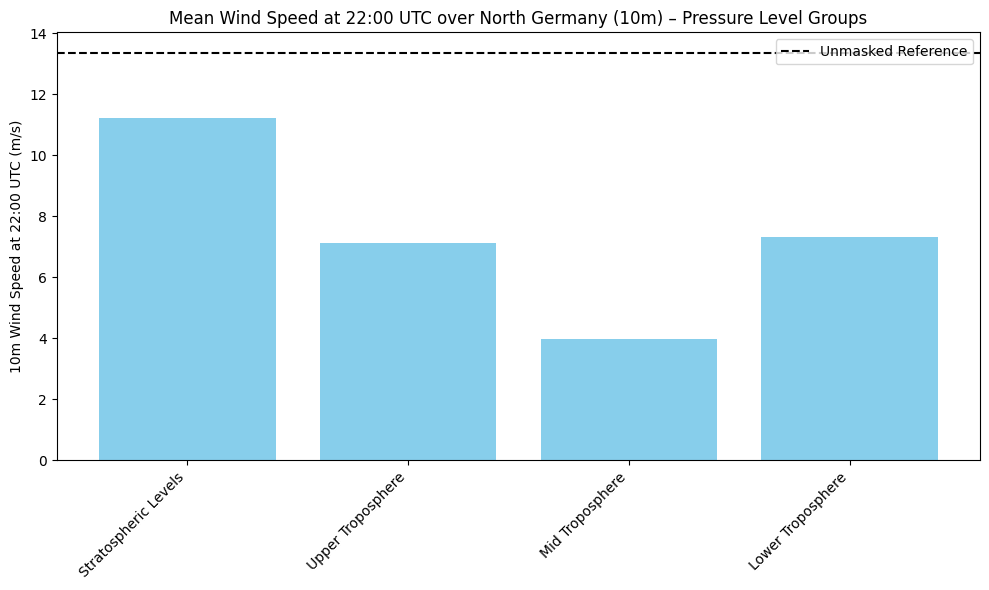

In [8]:
rename_map = {
    "none_lev(50, 100, 150, 200)_regnone_tnone": "Stratospheric Levels",
    "none_lev(250, 300, 400)_regnone_tnone": "Upper Troposphere",
    "none_lev(500, 600, 700)_regnone_tnone": "Mid Troposphere",
    "none_lev(850, 925, 1000)_regnone_tnone": "Lower Troposphere"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/pressure_level_groups",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Pressure Level Groups",
    rename_map=rename_map,
    order=[
        "Stratospheric Levels",
        "Upper Troposphere",
        "Mid Troposphere",
        "Lower Troposphere"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipyker

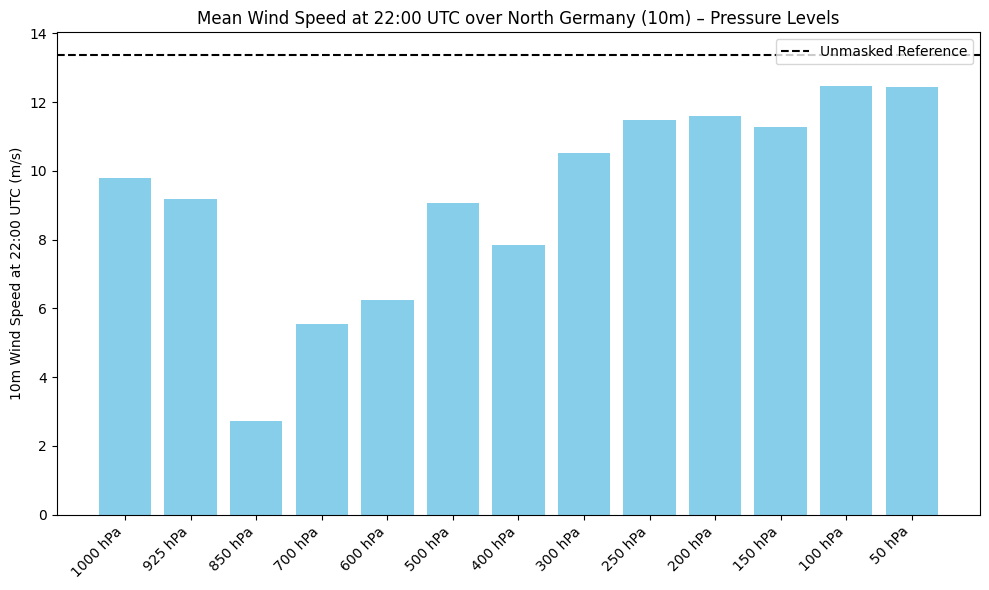

In [9]:
rename_map = {
    "none_lev1000_regnone_tnone": "1000 hPa",
    "none_lev925_regnone_tnone": "925 hPa",
    "none_lev850_regnone_tnone": "850 hPa",
    "none_lev700_regnone_tnone": "700 hPa",
    "none_lev600_regnone_tnone": "600 hPa",
    "none_lev500_regnone_tnone": "500 hPa",
    "none_lev400_regnone_tnone": "400 hPa",
    "none_lev300_regnone_tnone": "300 hPa",
    "none_lev250_regnone_tnone": "250 hPa",
    "none_lev200_regnone_tnone": "200 hPa",
    "none_lev150_regnone_tnone": "150 hPa",
    "none_lev100_regnone_tnone": "100 hPa",
    "none_lev50_regnone_tnone": "50 hPa"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/pressure_levels",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Pressure Levels",
    rename_map=rename_map,
    order=[
        "1000 hPa",
        "925 hPa",
        "850 hPa",
        "700 hPa",
        "600 hPa",
        "500 hPa",
        "400 hPa",
        "300 hPa",
        "250 hPa",
        "200 hPa",
        "150 hPa",
        "100 hPa",
        "50 hPa"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_34718/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipyker

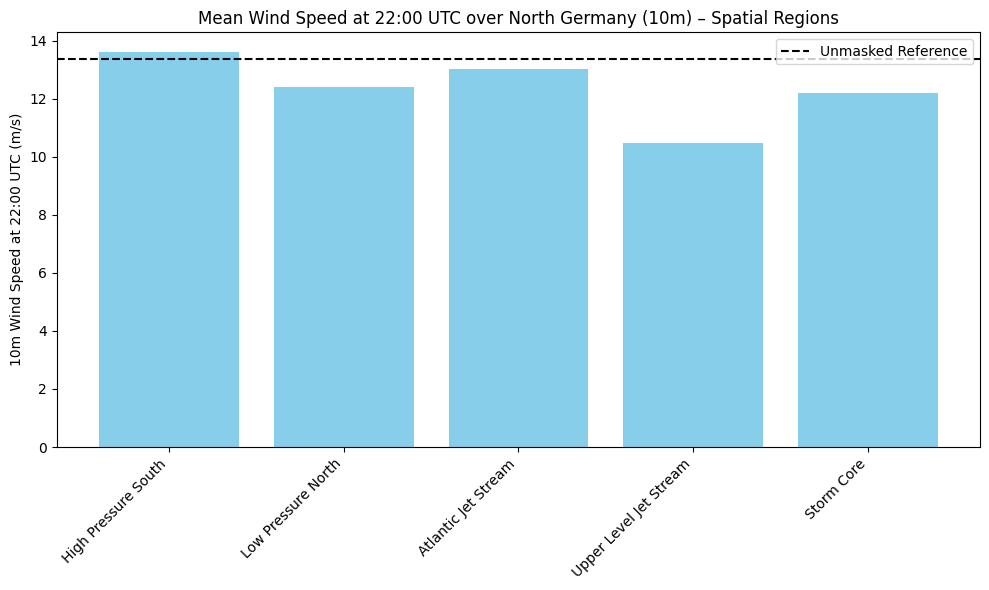

In [11]:
rename_map = {
    "none_levnone_regatlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "none_levnone_reghigh_pressure_south_tnone": "High Pressure South",
    "none_levnone_reglow_pressure_north_tnone": "Low Pressure North",
    "none_levnone_regnorth_germany_tnone": "North Germany",
    "none_levnone_regstorm_core_10utc_tnone": "Storm Core at 10 UTC",
    "none_levnone_regstorm_core_16utc_tnone": "Storm Core at 16 UTC",
    "none_levnone_regstorm_region_tnone": "Storm Region",
    "none_levnone_reg('storm_core_10utc', 'storm_core_16utc')_tnone": "Storm Core at 10 and 16 UTC",
    "none_levnone_regstorm_core_tnone": "Storm Core",
    "none_levnone_regdynamic_uljs_tnone": "Upper Level Jet Stream",
    "none_levnone_regstorm_core_t0": "Storm Core T0",
    "none_levnone_regstorm_core_t1": "Storm Core T1"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/spatial_regions",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Spatial Regions",
    rename_map=rename_map,
    order=[
        "High Pressure South",
        "Low Pressure North",
        "Atlantic Jet Stream",
        "Upper Level Jet Stream",
        "Storm Core"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16448/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16448/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_16448/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipyker

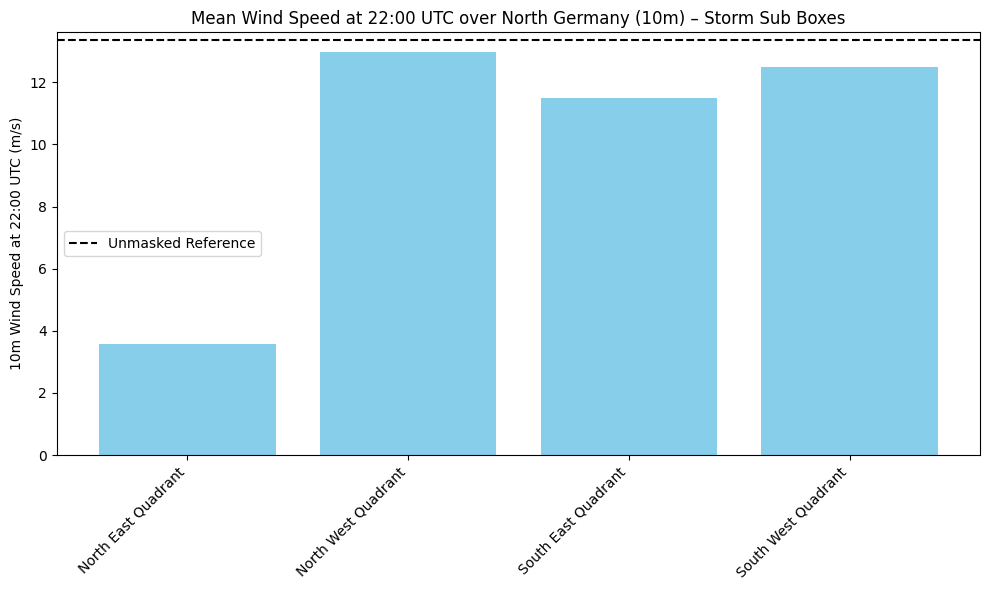

In [40]:
rename_map = {
    "none_levnone_regquad_ne_tnone": "North East Quadrant",
    "none_levnone_regquad_nw_tnone": "North West Quadrant",
    "none_levnone_regquad_se_tnone": "South East Quadrant",
    "none_levnone_regquad_sw_tnone": "South West Quadrant"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/storm_sub_boxes",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Storm Sub Boxes",
    rename_map=rename_map
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_53912/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_53912/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_53912/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)


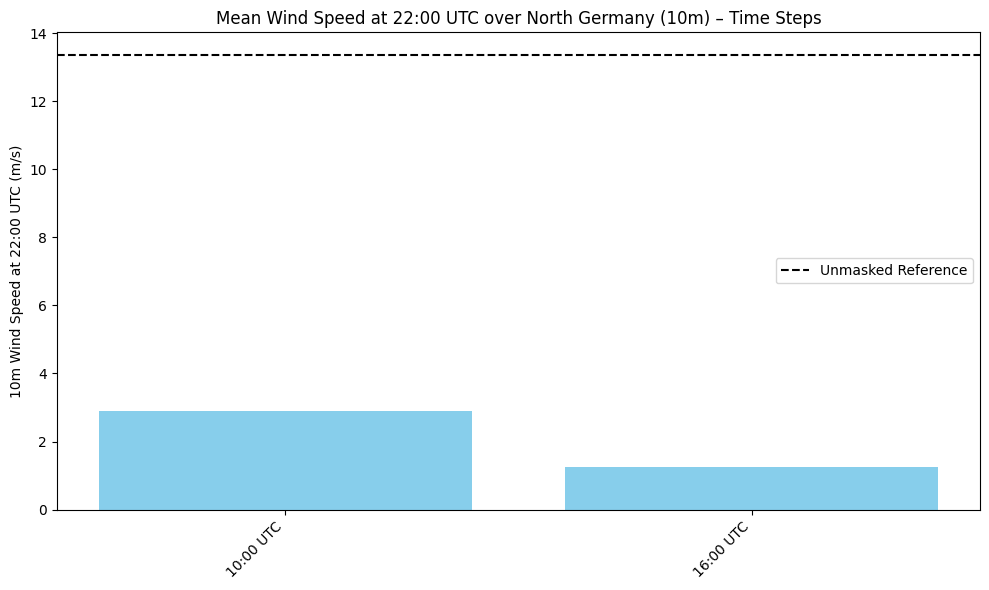

In [64]:
rename_map = {
    "none_levnone_regnone_t0": "10:00 UTC",
    "none_levnone_regnone_t1": "16:00 UTC",
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/time_steps",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Time Steps",
    rename_map=rename_map
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_27012/47767961.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_27012/47767961.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_27012/47767961.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_27

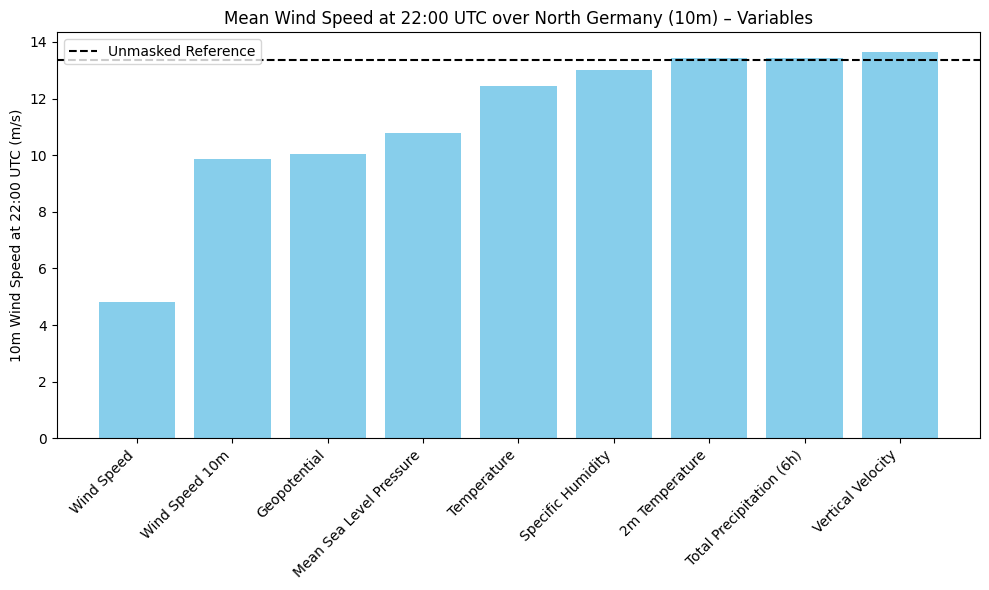

In [13]:
rename_map = {
    "2m_temperature_levnone_regnone_tnone": "2m Temperature",
    "mean_sea_level_pressure_levnone_regnone_tnone": "Mean Sea Level Pressure",
    "total_precipitation_6hr_levnone_regnone_tnone": "Total Precipitation (6h)",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone_regnone_tnone": "Wind Speed 10m",
    "temperature_levnone_regnone_tnone": "Temperature",
    "u_component_of_wind_levnone_regnone_tnone": "U Wind",
    "v_component_of_wind_levnone_regnone_tnone": "V Wind",
    "geopotential_levnone_regnone_tnone": "Geopotential",
    "vertical_velocity_levnone_regnone_tnone": "Vertical Velocity",
    "specific_humidity_levnone_regnone_tnone": "Specific Humidity",
    "('u_component_of_wind', 'v_component_of_wind')_levnone_regnone_tnone": "Wind Speed"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/all_variables",
    input_path=original_prediction_path,
    title = "Mean Wind Speed at 22:00 UTC over North Germany (10m) – Variables",
    rename_map=rename_map,
    order_by_size=True
)